# Stellar Colors in JWST Filters

This notebook demonstrates how to use the stellar colors table to analyze stellar photometry in JWST filters.

## Overview

The stellar colors table contains computed magnitudes for stellar atmosphere models with varying effective temperatures, spanning from cool M dwarfs (2000K) to hot O stars (50000K). This allows us to:

- Study how stellar colors vary with temperature
- Create color-color diagrams for different spectral types
- Analyze the sensitivity of different JWST filters to stellar properties
- Use as a reference for stellar photometry studies

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
import os
import sys

# Add the icemodels package to the path
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

# Set up plotting style
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("Imports completed successfully!")

        Use pytest instead. [astropy.tests.runner]
        Use pytest instead. [astropy.utils.decorators]


Imports completed successfully!


## Load the Stellar Colors Table

In [2]:
def load_stellar_colors():
    """Load the stellar colors table."""
    # Path to the data file
    table_path = '../icemodels/data/stellar_colors_in_filters.ecsv'

    if not os.path.exists(table_path):
        raise FileNotFoundError(f"Stellar colors table not found at {table_path}")

    return Table.read(table_path)

# Load the table
try:
    tbl = load_stellar_colors()
    print(f"✓ Successfully loaded stellar colors table")
    print(f"  - {len(tbl)} stellar models")
    print(f"  - Temperature range: {tbl['temperature'].min():.0f}K - {tbl['temperature'].max():.0f}K")
    print(f"  - Available filters: {len([col for col in tbl.colnames if col not in ['temperature', 'model_type', 'spectral_type']])}")
except Exception as e:
    print(f"✗ Error loading table: {e}")
    print("Make sure to run 'python -m icemodels.stellar_colors_in_filters' first to generate the table.")

✓ Successfully loaded stellar colors table
  - 50 stellar models
  - Temperature range: 2000K - 10000K
  - Available filters: 37


## Explore the Data Structure

In [3]:
# Show table info
print("Table columns:")
for col in tbl.colnames:
    print(f"  - {col}")

print(f"\nTable shape: ({len(tbl)}, {len(tbl.colnames)})")
print(f"\nFirst few rows:")
tbl[:5]  # Show first 5 rows

Table columns:
  - temperature
  - model_type
  - spectral_type
  - F115W
  - F150W
  - F162M
  - F182M
  - F187N
  - F200W
  - F210M
  - F212N
  - F250M
  - F277W
  - F300M
  - F323N
  - F322W2
  - F335M
  - F356W
  - F360M
  - F405N
  - F410M
  - F430M
  - F444W
  - F460M
  - F466N
  - F470N
  - F480M
  - F560W
  - F770W
  - F1000W
  - F1065C
  - F1130W
  - F1140C
  - F1280W
  - F1500W
  - F1550C
  - F1800W
  - F2100W
  - F2300C
  - F2550W

Table shape: (50, 40)

First few rows:


temperature,model_type,spectral_type,F115W,F150W,F162M,F182M,F187N,F200W,F210M,F212N,F250M,F277W,F300M,F323N,F322W2,F335M,F356W,F360M,F405N,F410M,F430M,F444W,F460M,F466N,F470N,F480M,F560W,F770W,F1000W,F1065C,F1130W,F1140C,F1280W,F1500W,F1550C,F1800W,F2100W,F2300C,F2550W
,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
float64,str18,str1,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
2000.0,stellar_atmosphere,M,-13.596916941049216,-13.76081028759263,-13.899252197387463,-13.380444491154444,-13.306446296900805,-13.425556797077336,-13.53351579000785,-13.567523475264933,-13.677821555917047,-14.094296504355404,-14.46559434967937,-14.444757318480423,-14.67655699809061,-14.679260763485571,-15.096658822747264,-15.238220511325093,-15.53404843885585,-15.49532193396401,-15.450004967046798,-15.417757342999254,-15.3490698285791,-15.393413190123761,-15.375499948219897,-15.374649718084177,-15.408599593076815,-15.515323574173564,-15.992314912526952,-16.03467860750222,-16.09333678094997,-16.096967605183767,-16.12645712009042,-16.171175049482315,-16.185420488892092,-16.23495101593203,-16.275934585576394,-16.301803287461333,-16.359007998999985
2066.7820908657573,stellar_atmosphere,M,-13.589415044290401,-13.793440696307481,-13.926094622317173,-13.451491403298942,-13.385291218018336,-13.4898940392932,-13.587299468718417,-13.61902199681361,-13.733919545700196,-14.116581477126608,-14.465721380614763,-14.537905475169378,-14.677127758894233,-14.742062774894183,-15.090987224123378,-15.225250841566641,-15.474868640409188,-15.438599220062416,-15.394163698320778,-15.357421187824157,-15.28107523208911,-15.327019114274592,-15.309870890708124,-15.31153517405587,-15.363107818616372,-15.476610417429406,-15.922333559355428,-15.965238268484331,-16.01902077830883,-16.02258756408666,-16.04691642871336,-16.087600665360398,-16.10315130542601,-16.14896952558434,-16.188616744967938,-16.213689255994,-16.269488273439006
2135.794105561713,stellar_atmosphere,M,-13.574695098887267,-13.821208973405,-13.950599685028566,-13.519038806146789,-13.460813737673691,-13.553230872509754,-13.642293021479368,-13.672195777207126,-13.790191439381196,-14.13959503796918,-14.466252258494327,-14.631829171510457,-14.678041884563598,-14.803876394955653,-15.085212201834082,-15.209408885700299,-15.414331690266996,-15.380334813634619,-15.337524839347951,-15.29736472405924,-15.21600972250966,-15.262686620048422,-15.245451768227465,-15.250132449815847,-15.317886437534584,-15.43994893481816,-15.851914892434154,-15.895237059378315,-15.943893071551958,-15.947402214225502,-15.966087012398773,-16.0029193812864,-16.01897549688174,-16.061359175386126,-16.099152536622736,-16.123411420539902,-16.178608431683262
2207.1105035757982,stellar_atmosphere,M,-13.551722569533117,-13.843607384772628,-13.97248387184874,-13.58333253388426,-13.53322100128951,-13.61567213865835,-13.69854356774841,-13.727172921405181,-13.846146789267443,-14.16269148751902,-14.466372604009084,-14.723899364097036,-14.678441581502922,-14.862733033224893,-15.07830237895639,-15.189385640902177,-15.352716097726784,-15.320691168080707,-15.280375907247443,-15.238419168315364,-15.155930197672769,-15.202193671141186,-15.18404294352779,-15.1919628580041,-15.273011556411813,-15.405033757859785,-15.781678919395269,-15.825343774299668,-15.868536007734821,-15.871975751847266,-15.88465454909712,-15.918059199440348,-15.93354709422475,-15.973092614696881,-16.008727640054754,-16.03230917972295,-16.08760475593494
2280.808230676081,stellar_atmosphere,M,-13.51997335198796,-13.857824327963453,-13.990320431054212,-13.644334122078162,-13.60184507766617,-13.67737806057637,-13.756513162227042,-13.785119007972026,-13.897787382057604,-14.180458002537637,-14.458901815801495,-14.795169072413572,-14.670845756869653,-14.902548042434491,

## Summary Statistics by Spectral Type

In [4]:
# Analyze models by spectral type
print("Models by spectral type:")
for spec_type in np.unique(tbl['spectral_type']):
    mask = tbl['spectral_type'] == spec_type
    temp_range = f"{tbl[mask]['temperature'].min():.0f}-{tbl[mask]['temperature'].max():.0f}K"
    count = np.sum(mask)
    print(f"  {spec_type}: {count} models ({temp_range})")

# Show example magnitudes for different spectral types
print(f"\nExample magnitudes for different spectral types:")
for spec_type in ['M', 'G', 'A', 'B', 'O']:
    mask = tbl['spectral_type'] == spec_type
    if np.sum(mask) > 0:
        idx = np.where(mask)[0][0]  # First occurrence
        temp = tbl[idx]['temperature']
        print(f"\n{spec_type} star ({temp:.0f}K):")
        for filt in ['F115W', 'F212N', 'F444W', 'F1000W']:
            if filt in tbl.colnames:
                print(f"  {filt}: {tbl[idx][filt]:.2f} mag")

Models by spectral type:
  A: 8 models (7689-9677K)
  B: 1 models (10000-10000K)
  F: 7 models (6110-7441K)
  G: 4 models (5358-5912K)
  K: 11 models (3733-5184K)
  M: 19 models (2000-3612K)

Example magnitudes for different spectral types:

M star (2000K):
  F115W: -13.60 mag
  F212N: -13.57 mag
  F444W: -15.42 mag
  F1000W: -15.99 mag

G star (5358K):
  F115W: -12.61 mag
  F212N: -13.20 mag
  F444W: -13.18 mag
  F1000W: -13.25 mag

A star (7689K):
  F115W: -11.90 mag
  F212N: -12.05 mag
  F444W: -12.05 mag
  F1000W: -12.06 mag

B star (10000K):
  F115W: -11.19 mag
  F212N: -11.18 mag
  F444W: -11.16 mag
  F1000W: -11.17 mag


## Color vs Temperature Analysis

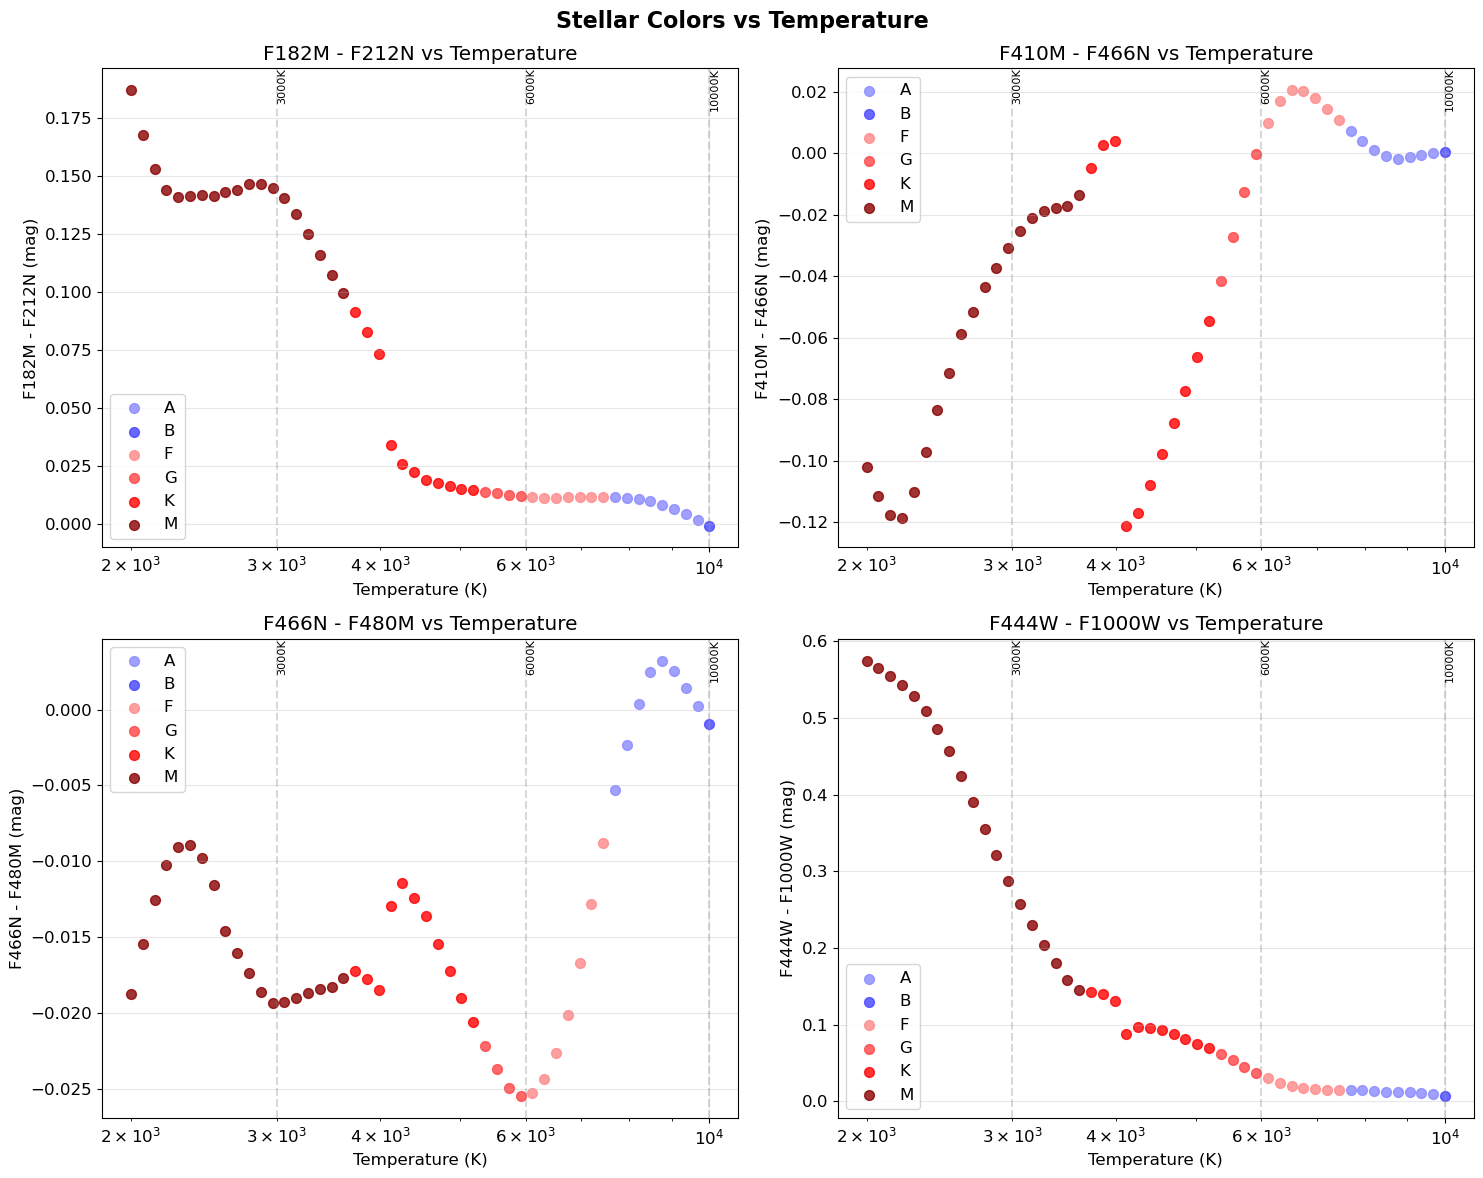

In [5]:
# Create a comprehensive color vs temperature plot
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Stellar Colors vs Temperature', fontsize=16, fontweight='bold')

# Define interesting color combinations (matching colorcolordiagrams.py)
color_combinations = [
    ('F182M', 'F212N', 'F182M - F212N'),
    ('F410M', 'F466N', 'F410M - F466N'),
    ('F466N', 'F480M', 'F466N - F480M'),
    ('F444W', 'F1000W', 'F444W - F1000W')
]

# Spectral type colors for plotting
spec_colors = {
    'O': '#0000FF',  # Blue
    'B': '#4444FF',  # Light blue
    'A': '#8888FF',  # Very light blue
    'F': '#FF8888',  # Light red
    'G': '#FF4444',  # Red
    'K': '#FF0000',  # Dark red
    'M': '#880000'   # Very dark red
}

for i, (filt1, filt2, color_name) in enumerate(color_combinations):
    ax = axes[i//2, i%2]

    if filt1 in tbl.colnames and filt2 in tbl.colnames:
        color = tbl[filt1] - tbl[filt2]

        # Plot by spectral type with different colors
        for spec_type in np.unique(tbl['spectral_type']):
            mask = tbl['spectral_type'] == spec_type
            if np.sum(mask) > 0:
                ax.scatter(tbl[mask]['temperature'], color[mask],
                          c=spec_colors[spec_type], label=spec_type, s=50, alpha=0.8)

        ax.set_xlabel('Temperature (K)')
        ax.set_ylabel(f'{color_name} (mag)')
        ax.set_title(f'{color_name} vs Temperature')
        ax.grid(True, alpha=0.3)
        ax.legend()

        # Use log scale for temperature
        ax.set_xscale('log')

        # Add some temperature annotations
        for temp in [3000, 6000, 10000, 20000, 40000]:
            if temp >= tbl['temperature'].min() and temp <= tbl['temperature'].max():
                ax.axvline(temp, color='gray', alpha=0.3, linestyle='--')
                ax.text(temp, ax.get_ylim()[1], f'{temp}K',
                       rotation=90, verticalalignment='top', fontsize=8)

plt.tight_layout()
plt.show()

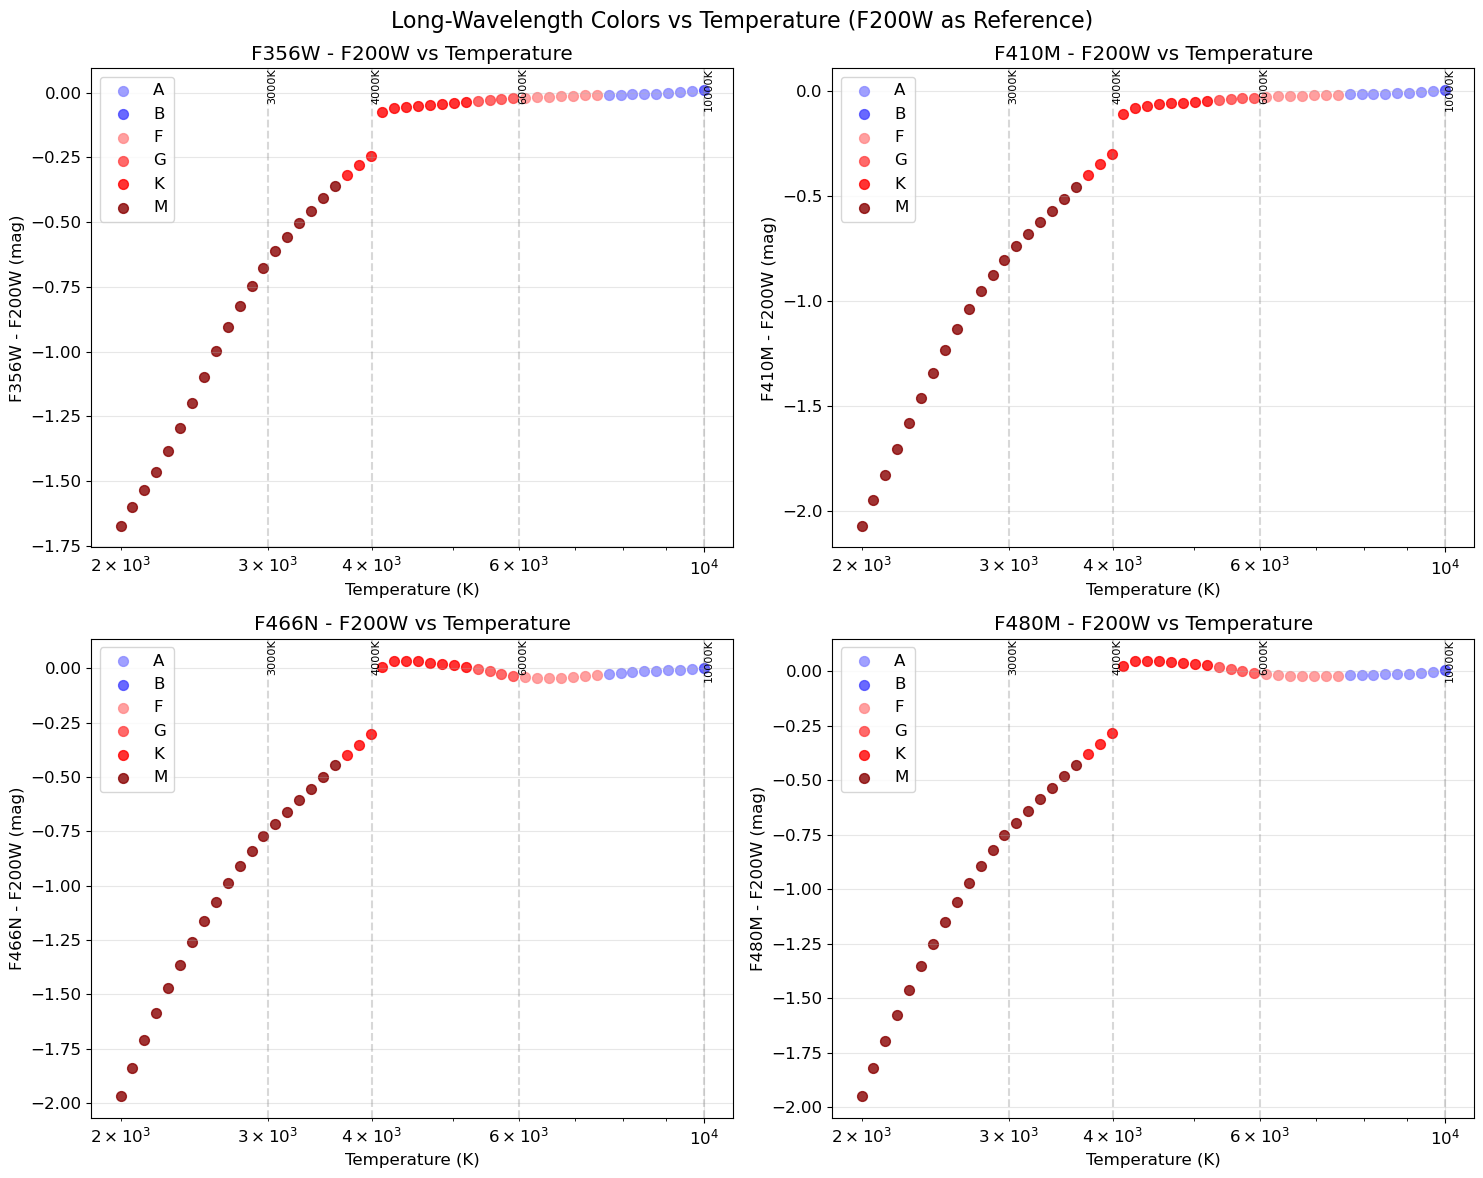

In [6]:
# Create color vs temperature plots for long-wavelength filters relative to F200W
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Long-Wavelength Colors vs Temperature (F200W as Reference)', fontsize=16)

# Define long-wavelength filters to compare with F200W
long_wave_filters = ['F356W', 'F410M', 'F466N', 'F480M']
reference_filter = 'F200W'

# Spectral type colors for plotting
spec_colors = {
    'O': '#0000FF',  # Blue
    'B': '#4444FF',  # Light blue
    'A': '#8888FF',  # Very light blue
    'F': '#FF8888',  # Light red
    'G': '#FF4444',  # Red
    'K': '#FF0000',  # Dark red
    'M': '#880000'   # Very dark red
}

for i, long_filt in enumerate(long_wave_filters):
    ax = axes[i//2, i%2]

    if long_filt in tbl.colnames and reference_filter in tbl.colnames:
        color = tbl[long_filt] - tbl[reference_filter]

        # Plot by spectral type with different colors
        for spec_type in np.unique(tbl['spectral_type']):
            mask = tbl['spectral_type'] == spec_type
            if np.sum(mask) > 0:
                ax.scatter(tbl[mask]['temperature'], color[mask],
                          c=spec_colors[spec_type], label=spec_type, s=50, alpha=0.8)

        ax.set_xlabel('Temperature (K)')
        ax.set_ylabel(f'{long_filt} - {reference_filter} (mag)')
        ax.set_title(f'{long_filt} - {reference_filter} vs Temperature')
        ax.grid(True, alpha=0.3)
        ax.legend()

        # Use log scale for temperature
        ax.set_xscale('log')

        # Add some temperature annotations
        for temp in [3000, 4000, 6000, 10000, 20000, 40000]:
            if temp >= tbl['temperature'].min() and temp <= tbl['temperature'].max():
                ax.axvline(temp, color='gray', alpha=0.3, linestyle='--')
                ax.text(temp, ax.get_ylim()[1], f'{temp}K',
                       rotation=90, verticalalignment='top', fontsize=8)
    else:
        ax.text(0.5, 0.5, f'Required filters not available\n({long_filt}, {reference_filter})',
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{long_filt} - {reference_filter} (filters not available)')

plt.tight_layout()
plt.show()


## Color-Color Diagrams

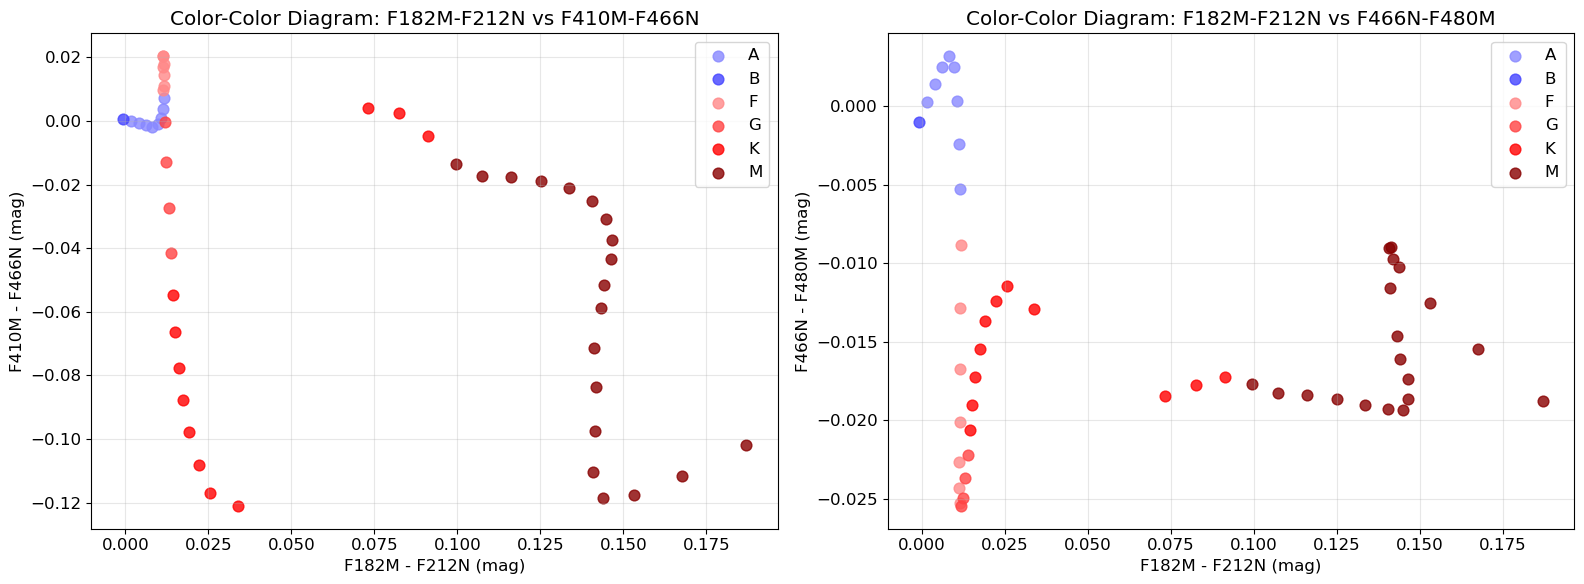

In [7]:
# Create multiple color-color diagrams
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Diagram 1: F182M-F212N vs F410M-F466N (matching colorcolordiagrams.py)
ax1 = axes[0]
if all(filt in tbl.colnames for filt in ['F182M', 'F212N', 'F410M', 'F466N']):
    x_color = tbl['F182M'] - tbl['F212N']
    y_color = tbl['F410M'] - tbl['F466N']

    for spec_type in np.unique(tbl['spectral_type']):
        mask = tbl['spectral_type'] == spec_type
        if np.sum(mask) > 0:
            ax1.scatter(x_color[mask], y_color[mask],
                       c=spec_colors[spec_type], label=spec_type, s=60, alpha=0.8)

    ax1.set_xlabel('F182M - F212N (mag)')
    ax1.set_ylabel('F410M - F466N (mag)')
    ax1.set_title('Color-Color Diagram: F182M-F212N vs F410M-F466N')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
else:
    ax1.text(0.5, 0.5, 'Required filters not available\n(F182M, F212N, F410M, F466N)',
             ha='center', va='center', transform=ax1.transAxes)
    ax1.set_title('F182M-F212N vs F410M-F466N (filters not available)')

# Diagram 2: F182M-F212N vs F466N-F480M (matching colorcolordiagrams.py)
ax2 = axes[1]
if all(filt in tbl.colnames for filt in ['F182M', 'F212N', 'F466N', 'F480M']):
    x_color = tbl['F182M'] - tbl['F212N']
    y_color = tbl['F466N'] - tbl['F480M']

    for spec_type in np.unique(tbl['spectral_type']):
        mask = tbl['spectral_type'] == spec_type
        if np.sum(mask) > 0:
            ax2.scatter(x_color[mask], y_color[mask],
                       c=spec_colors[spec_type], label=spec_type, s=60, alpha=0.8)

    ax2.set_xlabel('F182M - F212N (mag)')
    ax2.set_ylabel('F466N - F480M (mag)')
    ax2.set_title('Color-Color Diagram: F182M-F212N vs F466N-F480M')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'Required filters not available\n(F182M, F212N, F466N, F480M)',
             ha='center', va='center', transform=ax2.transAxes)
    ax2.set_title('F182M-F212N vs F466N-F480M (filters not available)')

plt.tight_layout()
plt.show()

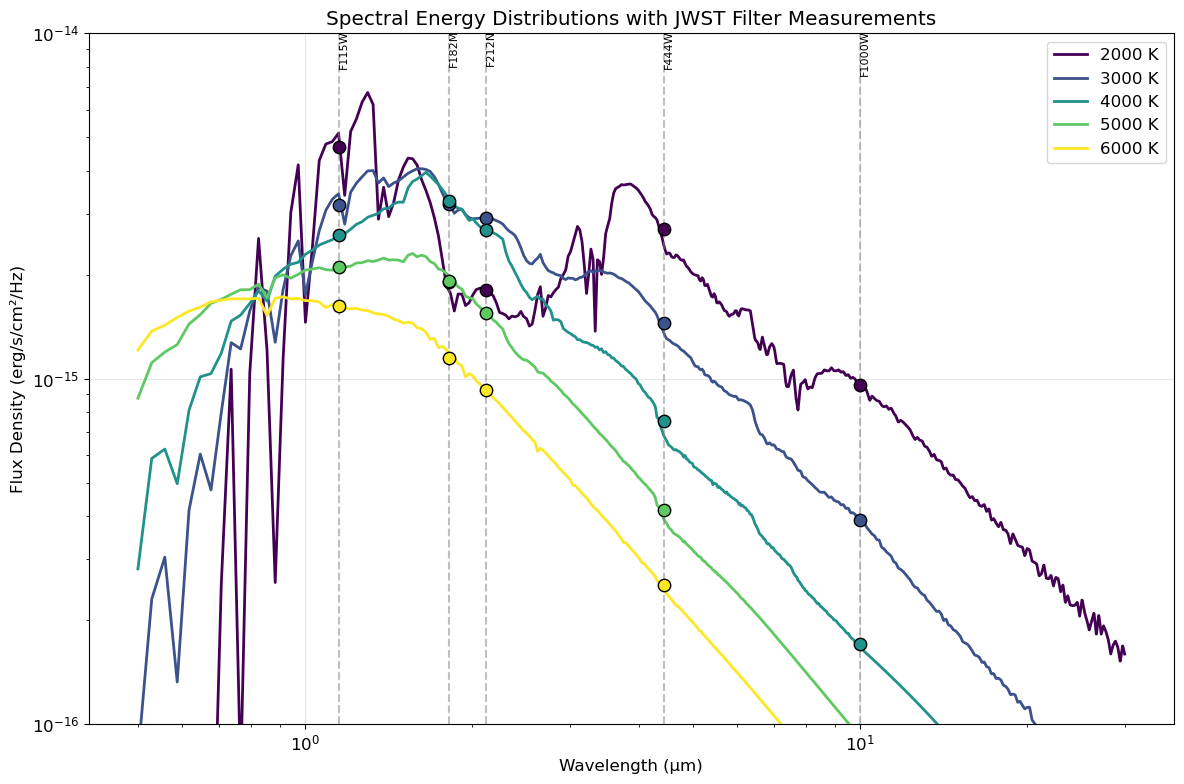

In [8]:
import astropy.units as u
from icemodels import atmo_model, fluxes_in_filters
from astroquery.svo_fps import SvoFps

# Define temperatures and wavelength range
temperatures = [2000, 3000, 4000, 5000, 6000]
wavelengths = np.linspace(0.5, 30, 1000) * u.micron

# Define JWST filters and their approximate central wavelengths
jwst_filters = ['F115W', 'F182M', 'F212N', 'F444W', 'F1000W']
filter_wavelengths = {
    'F115W': 1.15,
    'F182M': 1.82,
    'F212N': 2.12,
    'F444W': 4.44,
    'F1000W': 10.0
}

# Colors for different temperatures
colors = plt.cm.viridis(np.linspace(0, 1, len(temperatures)))

# Create the plot
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Generate SEDs for each temperature
for temp, color in zip(temperatures, colors):
    # Get atmospheric model for this temperature
    sed = atmo_model(temp, xarr=wavelengths)

    # Plot the SED
    ax.plot(wavelengths, sed['fnu'].quantity,
            color=color, linewidth=2,
            label=f'{temp} K')

    # Calculate filter fluxes and overlay as points
    try:
        # Get filter data for the JWST filters
        filter_ids = [f'JWST/NIRCam.{filt}' if filt != 'F1000W' else f'JWST/MIRI.{filt}'
                     for filt in jwst_filters]

        # Get transmission data for each filter individually (SvoFps API quirk)
        transdata = {}
        for filt_id in filter_ids:
            transdata[filt_id] = SvoFps.get_transmission_data(filt_id)

        # Calculate fluxes in the filters with proper transdata structure
        fluxes = fluxes_in_filters(wavelengths, sed['fnu'].quantity,
                                  filterids=filter_ids, transdata=transdata)

        # Plot flux measurements as points
        for filt, filt_id in zip(jwst_filters, filter_ids):
            if filt_id in fluxes:
                flux_val = fluxes[filt_id]
                wl = filter_wavelengths[filt] * u.micron
                ax.scatter(wl, flux_val, color=color, s=80, marker='o',
                          edgecolors='black', linewidth=1, zorder=5)

    except Exception as e:
        print(f"Could not calculate filter fluxes for {temp}K: {e}")
        raise

        # Fallback: interpolate flux at filter wavelengths from the SED
        for filt in jwst_filters:
            wl = filter_wavelengths[filt] * u.micron
            # Find closest wavelength in the SED
            idx = np.argmin(np.abs(wavelengths - wl))
            flux_approx = sed['fnu'].quantity[idx]
            ax.scatter(wl, flux_approx, color=color, s=80, marker='s',
                      edgecolors='black', linewidth=1, zorder=5, alpha=0.7)

# Customize the plot
ax.set_xlabel('Wavelength (μm)')
ax.set_ylabel('Flux Density (erg/s/cm²/Hz)')
ax.set_title('Spectral Energy Distributions with JWST Filter Measurements')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xscale('log')
ax.set_yscale('log')

# Add JWST filter bands as vertical lines for reference
for filt, wl in filter_wavelengths.items():
    ax.axvline(wl, color='gray', linestyle='--', alpha=0.5)
    ax.text(wl, ax.get_ylim()[1]*0.9, filt, rotation=90,
            verticalalignment='top', fontsize=8)

# Add legend explanation (not needed because the fallback is invalid)
# ax.text(0.02, 0.98, 'Circles: Filter flux measurements\nSquares: Interpolated (if filter calc fails)',
#         transform=ax.transAxes, verticalalignment='top', fontsize=10,
#         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.ylim(1e-16, 1e-14);
plt.tight_layout()
plt.show()


## Summary

This notebook demonstrates:

1. **Loading and exploring** the stellar colors table
2. **Color vs temperature relationships** for different JWST filters
3. **Color-color diagrams** showing stellar populations
4. **Interactive exploration** of specific temperature ranges

The stellar colors table provides a comprehensive reference for stellar photometry in JWST filters, spanning the full range of stellar temperatures from cool M dwarfs to hot O stars.